In [1]:
from platform import python_version
print("파이썬 버전:",python_version())

파이썬 버전: 3.13.5


생성된 데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_1   3000 non-null   float64
 1   col_2   3000 non-null   float64
 2   col_3   3000 non-null   float64
 3   col_4   3000 non-null   float64
 4   col_5   3000 non-null   float64
dtypes: float64(5)
memory usage: 117.3 KB


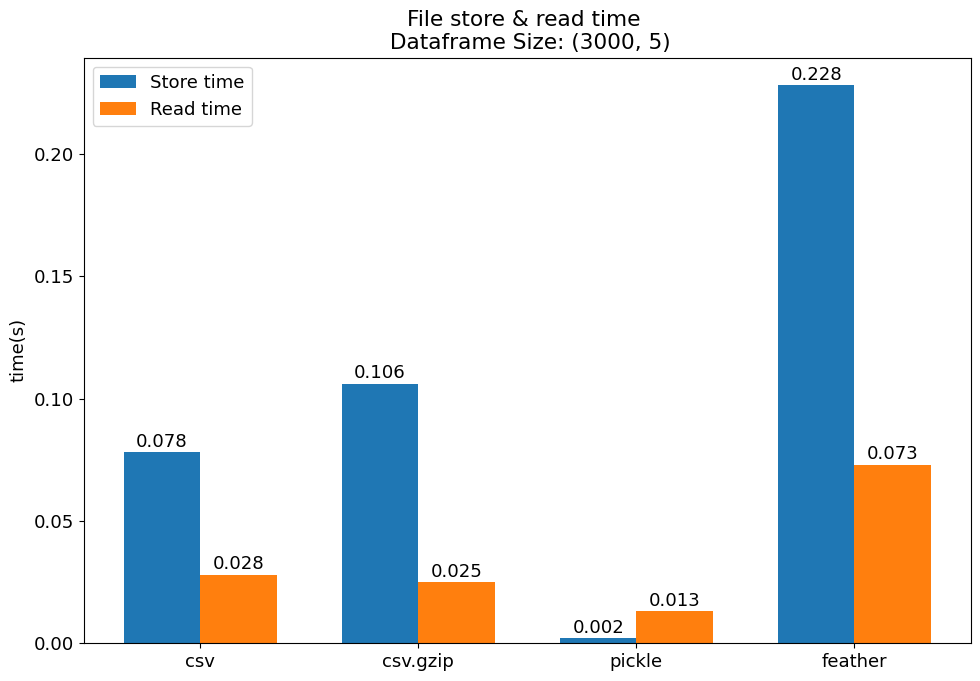

종료


In [1]:
import pandas as pd
import numpy as np
import random
from timeit import default_timer as timer

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def generate_dataframe(n_rows, n_cols):
    """주어진 행과 열의 숫자로 임의의 표준정규분포를 가진 데이터프레임을 만들다"""
    
    random_dataframe = {}

    for col in range(n_cols):
        col_name = f'col_{col+1}'
        values = np.random.normal(0, 1, n_rows)
        random_dataframe [col_name] = values
        
    return pd.DataFrame(random_dataframe)

def get_results(n_rows, n_cols):
    """
    1. generate_dataframe 호출
    2. csv, csv.gzip, pickle, feather 형태로 데이터 저장 및 처리시간 계산
    3. 처리시간을 그래프로 출력
    """

    df_sample = generate_dataframe(n_rows, n_cols)

    print("생성된 데이터 정보")
    df_sample.info()

    #테스트 종류
    test_list = ["csv", "csv.gzip", "pickle", "feather"]

    test_save_time =[]
    test_read_time =[]

    #실행1
    start = timer()
    df_sample.to_csv("../Python_Data/sample.csv")
    end = timer()
    test_save_time.append(round(end-start,3))    
    
    start = timer()
    pd.read_csv("../Python_Data/sample.csv")
    end = timer()
    test_read_time.append(round(end-start,3))
    
     #실행2
    start = timer()
    df_sample.to_csv("../Python_Data/sample_gzip.csv", compression='gzip')
    end = timer()
    test_save_time.append(round(end-start,3))

    start = timer()
    pd.read_csv("../Python_Data/sample_gzip.csv", compression='gzip')
    end = timer()
    test_read_time.append(round(end-start,3))
    
     #실행3
    start = timer()
    df_sample.to_pickle("../Python_Data/sample.pkl")
    end = timer()
    test_save_time.append(round(end-start,3))

    start = timer()
    pd.read_pickle("../Python_Data/sample.pkl")
    end = timer()
    test_read_time.append(round(end-start,3))
    
     #실행4
    start = timer()
    df_sample.to_feather("../Python_Data/sample.feather")
    end = timer()
    test_save_time.append(round(end-start,3))

    start = timer()
    pd.read_feather("../Python_Data/sample.feather")
    end = timer()
    test_read_time.append(round(end-start,3))
    
    #그래프 폰트 사이즈
    size = 13
    params = {'figure.figsize':[10,7],
              'legend.fontsize':size,
              'font.size':size,
              'figure.titlesize':size*1.3,
              'axes.labelsize':size,
              'xtick.labelsize':size,
              'ytick.labelsize':size}
    plt.rcParams.update(params)

    x=np.arange(len(test_list))
    width=0.35    
    fig, ax = plt.subplots()
    
    rects1 = ax.bar(x - width/2, test_save_time, width, label='Store time')
    rects2 = ax.bar(x + width/2, test_read_time, width, label='Read time')

    ax.set_title(f'File store & read time \n Dataframe Size: {df_sample.shape}')
    ax.set_ylabel('time(s)')
    ax.set_xticks(x)
    ax.set_xticklabels(test_list)
    ax.legend()

    #막대그래프 표기
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height}', #저장/읽기 시간 값
                        xy=(rect.get_x() + rect.get_width()/2, height), #값 위치
                        xytext =(0,4),
                        textcoords="offset points",
                        ha='center')

    autolabel(rects1)
    autolabel(rects2)
    fig.tight_layout()
    plt.show()

    #그래프 이미지 파일로 저장
    fig.savefig('../Python_Data/파일저장읽기시간그래프.png', dpi=200)
    print("종료")
    
#메인 함수    
get_results(3000,5) 